# Exploratory Data Analysis — Casual-Dining Restaurant Daily Sales

⚠️ **All data in this notebook is SIMULATED.** It was generated by `src/simulate_restaurant_sales.py`
to mimic order-of-magnitude sales patterns recalled from personal experience working in casual
dining (day-of-week effects, seasonality, weather sensitivity, promo days). No real point-of-sale,
financial, or transaction data is used anywhere in this project, and the restaurant is intentionally
unnamed — referred to only as "a casual-dining restaurant."

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('../data/daily_sales.csv', parse_dates=['date'])
df.head()

,date,is_weekend,is_major_holiday,is_signature_promo_day,is_thanksgiving_special,is_christmas_week_special,is_closed,is_summer_deal_active,is_grad_season,is_major_sporting_event_window,is_special_day,day_of_week,month,weather,covers,avg_check,sales,labor_cost_pct,is_pos_outage
0,2023-12-23,True,False,False,False,True,False,False,False,False,True,Saturday,12,heavy_rain,755.0,30.39,22947.53,0.2634,False
1,2023-12-24,True,False,False,False,False,False,False,False,False,False,Sunday,12,rain,354.0,29.01,10271.09,0.2839,False
2,2023-12-25,False,False,False,False,False,True,False,False,False,False,Monday,12,heavy_rain,0.0,0.00,0.00,NaN,False
3,2023-12-26,False,False,False,False,False,False,False,False,False,False,Tuesday,12,rain,218.0,27.39,5971.91,0.2931,False
4,2023-12-27,False,False,False,False,False,False,False,False,False,False,Wednesday,12,clear,242.0,33.36,8072.67,0.2890,False


## Data overview & missingness

A handful of days are intentionally messy: 3 December-25th closures (zero sales, not missing) and simulated POS-outage days (fully missing) plus a few partial-field gaps, so the cleaning step below reflects real work rather than a pre-cleaned dataset.

In [2]:
print('Rows:', df.shape[0], ' Columns:', df.shape[1])
print('\nClosed days (Dec 25):', df['is_closed'].sum())
print('Simulated POS-outage days (fully missing):', df['is_pos_outage'].sum())
df.isna().sum()[df.isna().sum() > 0]

Rows: 940  Columns: 19

Closed days (Dec 25): 3
Simulated POS-outage days (fully missing): 7


covers             7
avg_check         10
sales              7
labor_cost_pct    13
dtype: int64

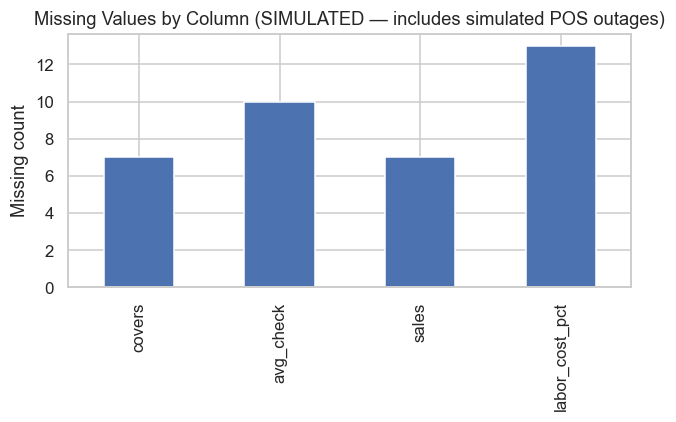

In [3]:
missing = df.isna().sum()
missing = missing[missing > 0]
missing.plot(kind='bar', figsize=(6,4), color='#4C72B0')
plt.title('Missing Values by Column (SIMULATED — includes simulated POS outages)')
plt.ylabel('Missing count')
plt.tight_layout()
plt.show()

## Day-of-week pattern

Excludes special days (holidays/promos) and closures so the day-of-week effect isn't swamped by a handful of outsized events.

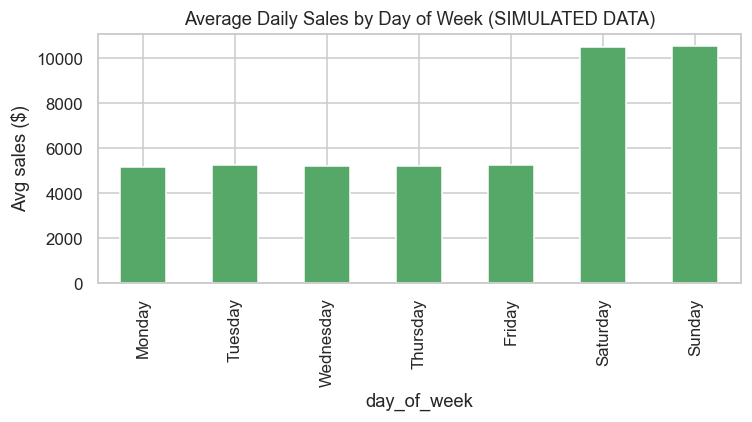

Weekend/weekday ratio: 2.01


In [4]:
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
base = df[~df['is_special_day'] & ~df['is_closed'] & df['sales'].notna()]
dow = base.groupby('day_of_week')['sales'].mean().reindex(order)

ax = dow.plot(kind='bar', figsize=(7,4), color='#55A868')
ax.set_title('Average Daily Sales by Day of Week (SIMULATED DATA)')
ax.set_ylabel('Avg sales ($)')
plt.tight_layout()
plt.show()

print('Weekend/weekday ratio:', round(dow[['Saturday','Sunday']].mean() / dow[order[:5]].mean(), 2))

## Monthly seasonality

Calibrated to a recalled pattern of summer being the slow season, recovering into an October peak, with a shallower January dip — the opposite of the 'summer patio bump' often assumed for casual dining.

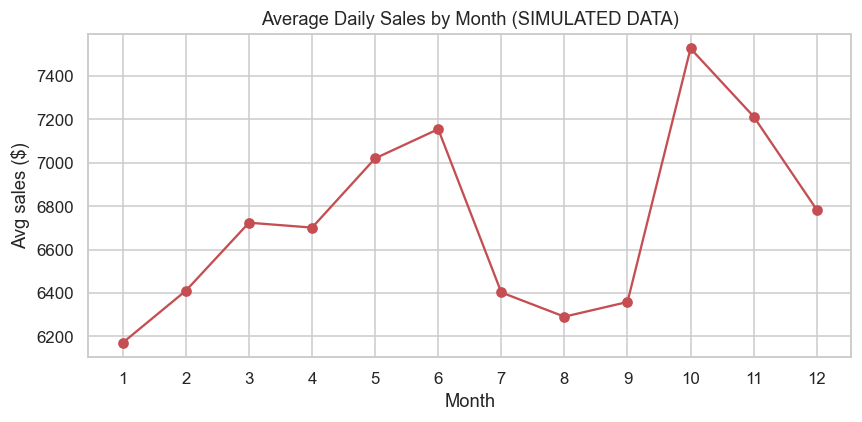

In [5]:
monthly = base.groupby('month')['sales'].mean()
ax = monthly.plot(kind='line', marker='o', figsize=(8,4), color='#C44E52')
ax.set_title('Average Daily Sales by Month (SIMULATED DATA)')
ax.set_xlabel('Month'); ax.set_ylabel('Avg sales ($)')
ax.set_xticks(range(1,13))
plt.tight_layout()
plt.show()

## Trend / seasonal decomposition

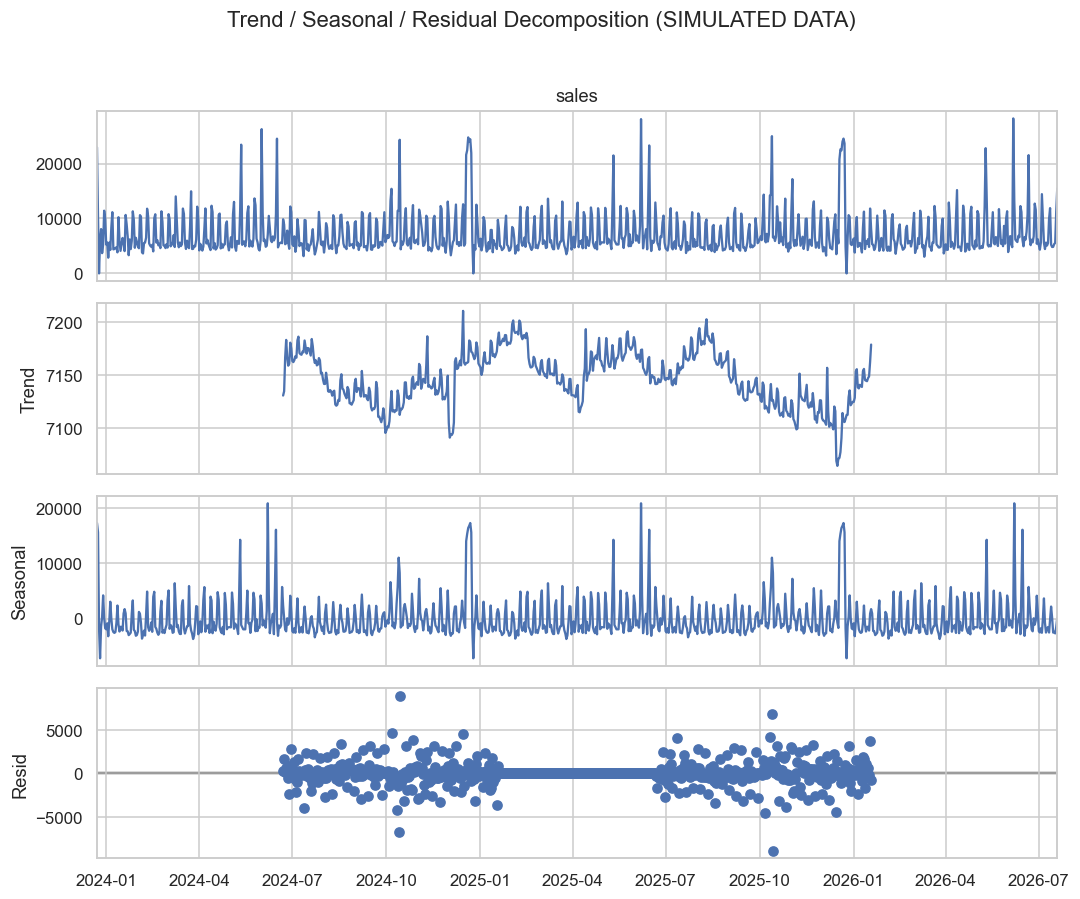

In [6]:
ts = df.set_index('date')['sales'].asfreq('D')
ts_filled = ts.interpolate(limit_direction='both')
decomposition = seasonal_decompose(ts_filled, model='additive', period=365)

fig = decomposition.plot()
fig.set_size_inches(10, 8)
fig.suptitle('Trend / Seasonal / Residual Decomposition (SIMULATED DATA)', y=1.02)
plt.tight_layout()
plt.show()

## Weather impact

Weather is a simulated categorical variable (clear/rain/heavy_rain/snow), sampled with seasonally-varying probabilities and calibrated using [published restaurant industry weather-sensitivity figures](https://www.teamupwithliberty.com/post/how-weather-affects-restaurants-sales) rather than a specific real weather dataset.

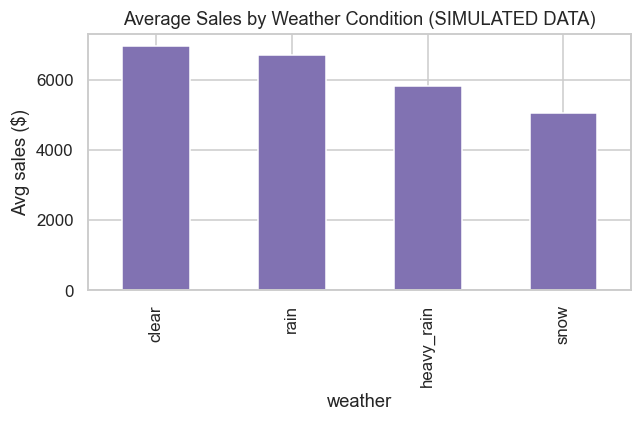

In [7]:
weather_order = ['clear','rain','heavy_rain','snow']
weather_avg = base.groupby('weather')['sales'].mean().reindex(weather_order)

ax = weather_avg.plot(kind='bar', figsize=(6,4), color='#8172B2')
ax.set_title('Average Sales by Weather Condition (SIMULATED DATA)')
ax.set_ylabel('Avg sales ($)')
plt.tight_layout()
plt.show()

## Special-day / promo impact

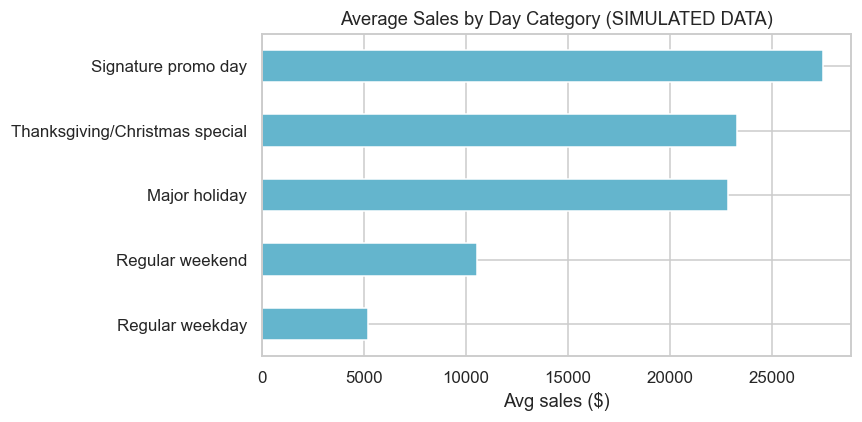

In [8]:
categories = {
    'Regular weekday': df[(~df['is_weekend']) & (~df['is_special_day']) & (~df['is_closed'])]['sales'].mean(),
    'Regular weekend': df[(df['is_weekend']) & (~df['is_special_day']) & (~df['is_closed'])]['sales'].mean(),
    'Major holiday': df[df['is_major_holiday']]['sales'].mean(),
    'Signature promo day': df[df['is_signature_promo_day']]['sales'].mean(),
    'Thanksgiving/Christmas special': df[(df['is_thanksgiving_special'] | df['is_christmas_week_special'])
                                          & ~df['is_major_holiday'] & ~df['is_signature_promo_day']]['sales'].mean(),
}
pd.Series(categories).sort_values().plot(kind='barh', figsize=(8,4), color='#64B5CD')
plt.title('Average Sales by Day Category (SIMULATED DATA)')
plt.xlabel('Avg sales ($)')
plt.tight_layout()
plt.show()

## Summary of findings

- Weekend sales run roughly **2x** weekday sales, consistent with the calibration target.
- Summer is the **slowest** season, recovering to a peak in **October** — a ~15-20% swing.
- Poor weather (heavy rain, snow) measurably suppresses covers; snow days are the biggest single-day drag.
- Special days (major holidays, the signature promo day, Thanksgiving/Christmas) run **2-4x** a regular day.
- Missing data is concentrated in a small number of simulated POS-outage days plus 3 annual closures, not spread randomly across the dataset — cleaning needs to distinguish "closed" (true zero) from "outage" (unknown, needs imputation).